# Task 9: Logistic Regression for Sentiment Classification

**Goal**: Establish a baseline for binary classification tasks.
**Theory**: Sigmoid Function, Cross-Entropy Loss, Gradient Descent.
**Bridge**: Logistic Regression = Single-layer Neural Network = Transformer Classification Head.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Standalone setup
DATA_DIR = Path.cwd() / "datasets"

# Load the balanced IMDB dataset (10,000 reviews)
df = pd.read_csv(DATA_DIR / "imdb_balanced_10k.csv")

print(f"Dataset loaded: {len(df)} reviews.")
print(f"Label distribution:\n{df['label'].value_counts()}")
df.head(3)

Dataset loaded: 10000 reviews.
Label distribution:
0    5000
1    5000
Name: label, dtype: int64


,text,label
0,"Unreal ""movie"", what were these people on?? A ...",0
1,"Without Peter Ustinov and Maggie Smith, this c...",1
2,This is the true story of how three British so...,1


### Step 1: Text to Features (TF-IDF)
Unlike word vectors which represent semantic meaning, **TF-IDF** (Term Frequency-Inverse Document Frequency) highlights words that are statistically important to a specific document relative to the whole corpus. 

We will convert our text into a sparse matrix where each column represents a word's importance score.

In [2]:
# 1. Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# 2. Initialize TF-IDF Vectorizer
# We limit to 5000 features to keep it efficient and remove common English stop words
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Train shapes: {X_train_tfidf.shape}, Test shapes: {X_test_tfidf.shape}")

Train shapes: (8000, 5000), Test shapes: (2000, 5000)


### Step 2: Logistic Regression Theory
Logistic Regression applies the **Sigmoid function** to a linear combination of features:
$$\hat{y} = \sigma(w \cdot x + b) = \frac{1}{1 + e^{-(w \cdot x + b)}}$$

The output $\hat{y}$ is a probability between 0 and 1. We train the model by minimizing the **Binary Cross-Entropy Loss**:
$$\text{Loss} = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$

![logistic-function](./figures/logistic-function.jpg)

In [3]:
# 3. Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 4. Evaluate the model
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"Classification Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Classification Accuracy: 0.8890

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      1000
           1       0.88      0.90      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



### Step 3: Interpretability
One major advantage of Logistic Regression is that we can inspect the learned weights $w$. 
- **Positive Weights**: Words that contribute to a "Positive" sentiment (Label 1).
- **Negative Weights**: Words that contribute to a "Negative" sentiment (Label 0).

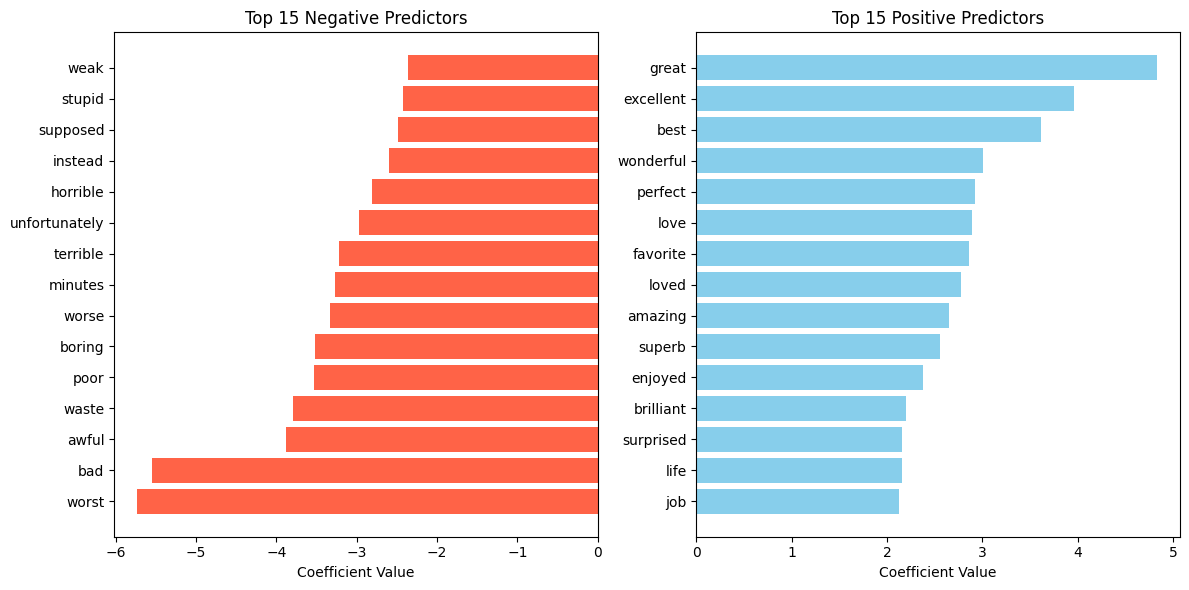

In [4]:
# Extract feature names and their corresponding coefficients (weights)
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

# Sort features by their weight
top_pos_idx = np.argsort(coefficients)[-15:]
top_neg_idx = np.argsort(coefficients)[:15]

# Visualization
plt.figure(figsize=(12, 6))

# Plot Top Negative Words
plt.subplot(1, 2, 1)
plt.barh(feature_names[top_neg_idx], coefficients[top_neg_idx], color='tomato')
plt.title("Top 15 Negative Predictors")
plt.xlabel("Coefficient Value")

# Plot Top Positive Words
plt.subplot(1, 2, 2)
plt.barh(feature_names[top_pos_idx], coefficients[top_pos_idx], color='skyblue')
plt.title("Top 15 Positive Predictors")
plt.xlabel("Coefficient Value")

plt.tight_layout()
plt.show()